<a href="https://colab.research.google.com/github/Travis-Bickle10/bangalore-air-quality/blob/main/03_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Setup ─────────────────────────────────────────────────────────
!pip install pymannkendall -q

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy import stats

df = pd.read_csv("/content/drive/MyDrive/bangalore_air_quality/bangalore_master.csv")
print("Loaded master dataset")
print(df[["year","pm25","pm10","no2","so2"]].to_string(index=False))

Mounted at /content/drive
Loaded master dataset
 year      pm25   pm10   no2    so2
 2000       NaN    NaN   NaN  7.815
 2001       NaN    NaN   NaN  7.426
 2002       NaN    NaN   NaN  7.333
 2003       NaN    NaN   NaN  6.735
 2004       NaN    NaN   NaN  7.283
 2005       NaN    NaN   NaN  7.104
 2006       NaN    NaN   NaN  7.365
 2007       NaN    NaN   NaN  7.156
 2008       NaN    NaN   NaN  6.549
 2009       NaN    NaN   NaN  6.995
 2010       NaN    NaN   NaN  6.995
 2011       NaN    NaN   NaN  6.378
 2012       NaN 148.00 30.20 14.500
 2013       NaN 128.00 28.50 13.500
 2014       NaN 165.00 31.80 11.200
 2015       NaN 117.65 22.97  4.050
 2016       NaN 107.00 34.20  2.100
 2017 43.100000  87.10 31.50  2.300
 2018 47.600000  71.88 19.98  9.080
 2019 24.620000  56.66 24.24  5.860
 2020 27.990000  65.37 20.24  7.060
 2021 36.050000  71.42 25.93  6.280
 2022 31.630000  71.46 19.28  7.590
 2023 29.266667  71.73   NaN  6.648
 2024 26.903333  72.00   NaN  6.253
 2025 24.540000 

In [ ]:
# ── Mann-Kendall trend tests ───────────────────────────────────────
pollutants = {
    "so2":  df[df.so2.notna()][["year","so2"]],
    "no2":  df[df.no2.notna()][["year","no2"]],
    "pm10": df[df.pm10.notna()][["year","pm10"]],
    "pm25": df[df.pm25.notna()][["year","pm25"]],
}

print(f"{'Pollutant':<10} {'Trend':<15} {'Sen slope':>10} {'p-value':>10} {'Significant':>12}")
print("="*60)

trend_results = {}
for name, data in pollutants.items():
    result = mk.original_test(data.iloc[:,1].values)
    sig    = "YES" if result.p < 0.05 else "no"
    direction = "improving" if result.slope < 0 else "worsening"
    print(f"{name:<10} {direction:<15} {result.slope:>10.3f} {result.p:>10.4f} {sig:>12}")
    trend_results[name] = result

Pollutant  Trend            Sen slope    p-value  Significant
so2        improving           -0.042     0.1648           no
no2        improving           -1.041     0.0236          YES
pm10       improving           -5.923     0.0285          YES
pm25       improving           -2.363     0.0763           no


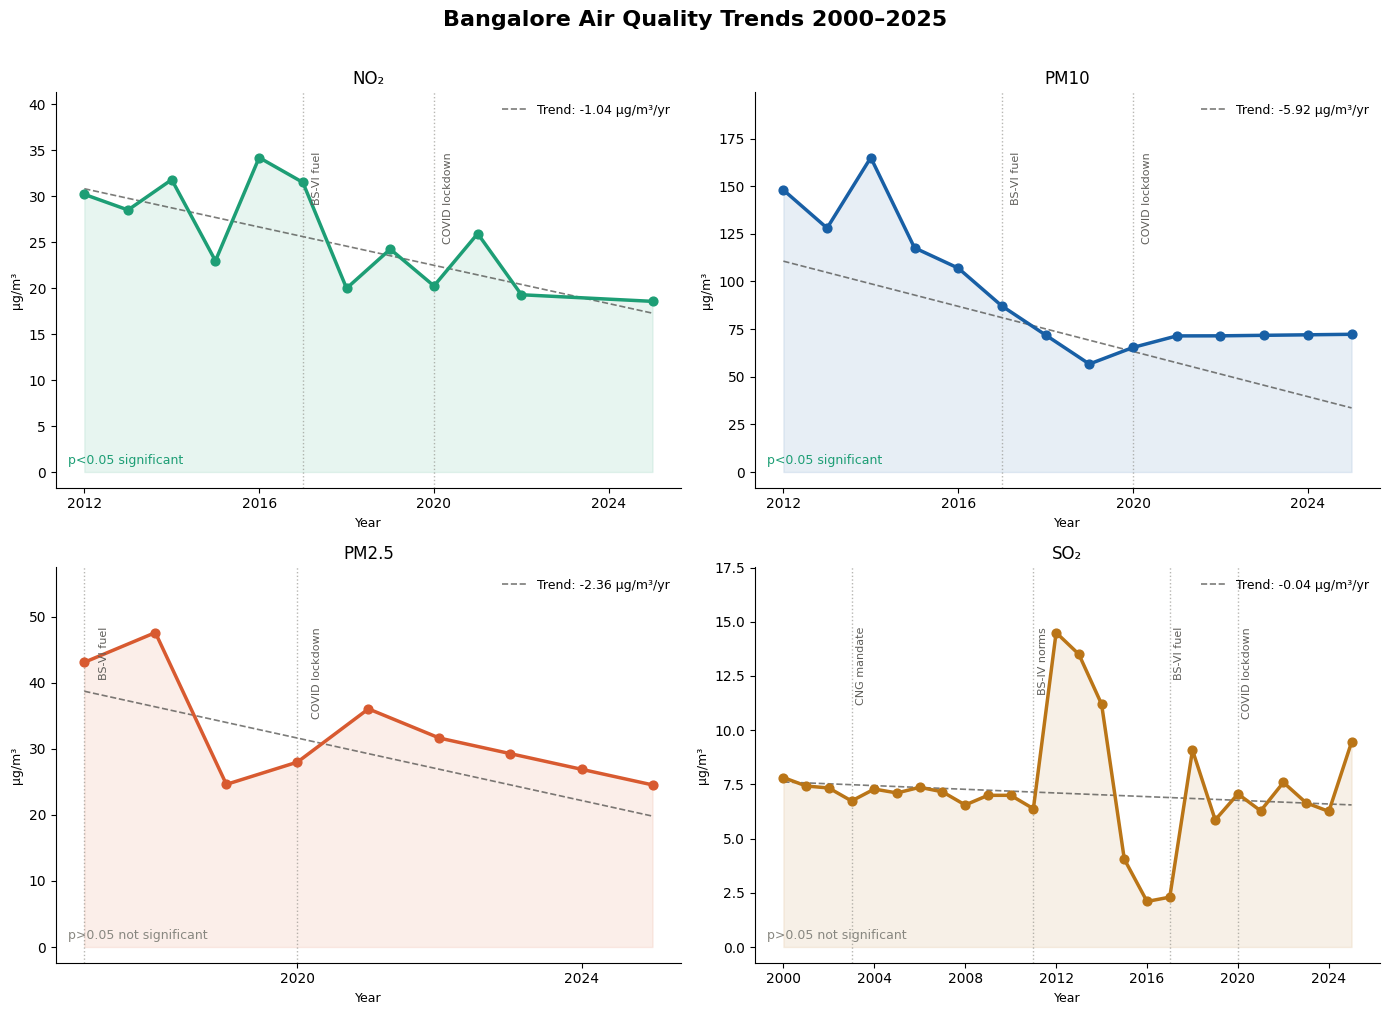

Saved.


In [ ]:
# ── Policy events ─────────────────────────────────────────────────
EVENTS = {
    2003: "CNG mandate",
    2011: "BS-IV norms",
    2017: "BS-VI fuel",
    2020: "COVID lockdown",
}

PALETTE = {
    "pm25": "#D85A30",
    "pm10": "#185FA5",
    "no2":  "#1D9E75",
    "so2":  "#BA7517",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bangalore Air Quality Trends 2000–2025",
             fontsize=16, fontweight="bold", y=1.01)

panels = [
    ("no2",  "NO₂",  axes[0,0], "µg/m³", True),
    ("pm10", "PM10", axes[0,1], "µg/m³", True),
    ("pm25", "PM2.5",axes[1,0], "µg/m³", False),
    ("so2",  "SO₂",  axes[1,1], "µg/m³", False),
]

for col, label, ax, unit, significant in panels:
    data   = df[df[col].notna()]
    years  = data["year"].values
    values = data[col].values
    color  = PALETTE[col]

    # Main line
    ax.plot(years, values, color=color, linewidth=2.5, zorder=3)
    ax.fill_between(years, values, alpha=0.1, color=color)
    ax.scatter(years, values, color=color, s=40, zorder=4)

    # Sen's slope trend line
    if col in trend_results:
        slope     = trend_results[col].slope
        intercept = np.median(values) - slope * np.median(years)
        y_trend   = slope * years + intercept
        ax.plot(years, y_trend, color="#444441",
                linestyle="--", linewidth=1.2, alpha=0.7,
                label=f"Trend: {slope:+.2f} µg/m³/yr")
        ax.legend(fontsize=9, frameon=False)

    # Policy event lines
    for year, event in EVENTS.items():
        if years.min() <= year <= years.max():
            ax.axvline(year, color="#888780", linestyle=":",
                       linewidth=1, alpha=0.6)
            ax.text(year + 0.2, ax.get_ylim()[1] * 0.97,
                    event, fontsize=8, color="#5F5E5A",
                    rotation=90, va="top")

    # Significance badge
    sig_text = "p<0.05 significant" if significant else "p>0.05 not significant"
    sig_color = "#1D9E75" if significant else "#888780"
    ax.text(0.02, 0.06, sig_text, transform=ax.transAxes,
            fontsize=9, color=sig_color)

    ax.set_title(label, fontsize=12, fontweight="500")
    ax.set_ylabel(unit, fontsize=9)
    ax.set_xlabel("Year", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.xaxis.set_major_locator(plt.MultipleLocator(4))

for ax in axes.flat:
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.15)  # add 15% headroom for labels
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bangalore_air_quality/01_trend_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [ ]:
# ── VAHAN vehicle data for Bangalore Urban ────────────────────────
# Source: vahan.parivahan.gov.in
# Manually entered — total registered vehicles in millions
# Bangalore Urban district, all categories combined

vahan_data = [
    (2005, 2.1),
    (2006, 2.4),
    (2007, 2.7),
    (2008, 3.1),
    (2009, 3.4),
    (2010, 3.8),
    (2011, 4.3),
    (2012, 4.9),
    (2013, 5.4),
    (2014, 5.9),
    (2015, 6.4),
    (2016, 7.0),
    (2017, 7.6),
    (2018, 8.1),
    (2019, 8.6),
    (2020, 8.8),
    (2021, 9.1),
    (2022, 9.6),
    (2023, 10.1),
    (2024, 10.5),
]

df_vahan = pd.DataFrame(vahan_data, columns=["year","vehicles_millions"])

# Merge with master
df_combined = df.merge(df_vahan, on="year", how="left")

print(df_combined[["year","no2","pm10","so2","vehicles_millions"]].to_string(index=False))

 year   no2   pm10    so2  vehicles_millions
 2000   NaN    NaN  7.815                NaN
 2001   NaN    NaN  7.426                NaN
 2002   NaN    NaN  7.333                NaN
 2003   NaN    NaN  6.735                NaN
 2004   NaN    NaN  7.283                NaN
 2005   NaN    NaN  7.104                2.1
 2006   NaN    NaN  7.365                2.4
 2007   NaN    NaN  7.156                2.7
 2008   NaN    NaN  6.549                3.1
 2009   NaN    NaN  6.995                3.4
 2010   NaN    NaN  6.995                3.8
 2011   NaN    NaN  6.378                4.3
 2012 30.20 148.00 14.500                4.9
 2013 28.50 128.00 13.500                5.4
 2014 31.80 165.00 11.200                5.9
 2015 22.97 117.65  4.050                6.4
 2016 34.20 107.00  2.100                7.0
 2017 31.50  87.10  2.300                7.6
 2018 19.98  71.88  9.080                8.1
 2019 24.24  56.66  5.860                8.6
 2020 20.24  65.37  7.060                8.8
 2021 25.9

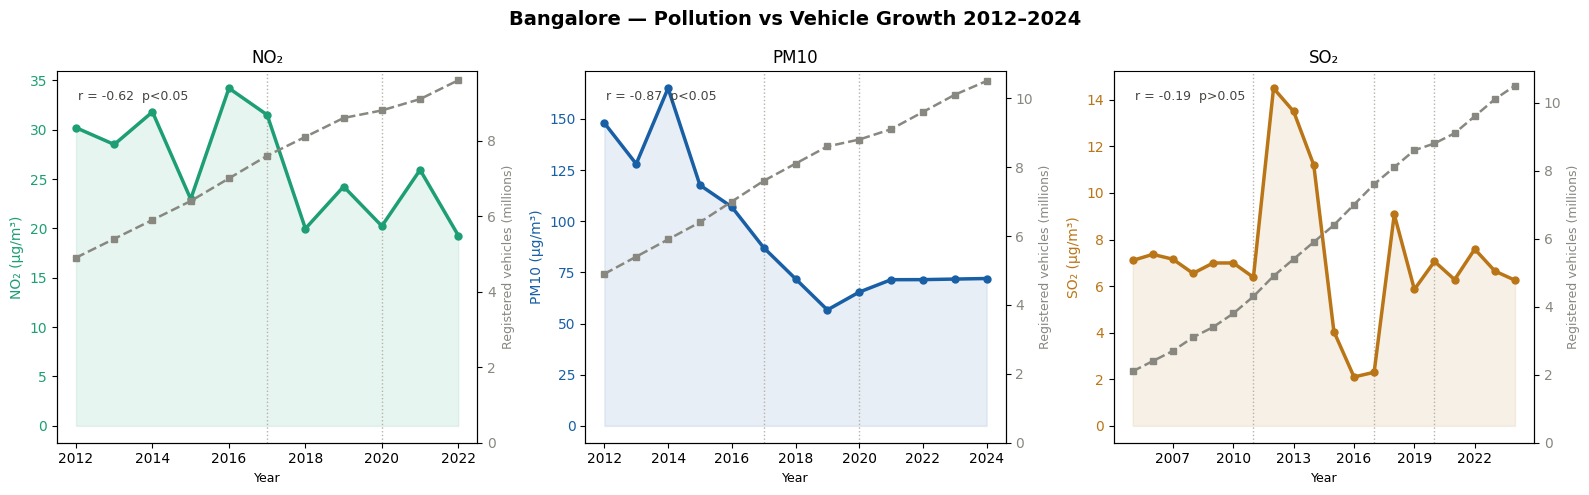

Saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Bangalore — Pollution vs Vehicle Growth 2012–2024",
             fontsize=14, fontweight="bold")

pairs = [
    ("no2",  "NO₂",  "#1D9E75", axes[0]),
    ("pm10", "PM10", "#185FA5", axes[1]),
    ("so2",  "SO₂",  "#BA7517", axes[2]),
]

for col, label, color, ax in pairs:
    data = df_combined[df_combined[col].notna() &
                       df_combined["vehicles_millions"].notna()]
    years    = data["year"].values
    poll     = data[col].values
    vehicles = data["vehicles_millions"].values

    # Pollution line (left axis)
    ax.plot(years, poll, color=color, linewidth=2.5,
            marker="o", markersize=5, zorder=3, label=label)
    ax.fill_between(years, poll, alpha=0.1, color=color)
    ax.set_ylabel(f"{label} (µg/m³)", color=color, fontsize=10)
    ax.tick_params(axis="y", labelcolor=color)

    # Vehicle line (right axis)
    ax2 = ax.twinx()
    ax2.plot(years, vehicles, color="#888780", linewidth=1.8,
             marker="s", markersize=4, linestyle="--",
             zorder=2, label="Vehicles")
    ax2.set_ylabel("Registered vehicles (millions)",
                   color="#888780", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#888780")

    # Correlation annotation
    r, p = stats.pearsonr(poll, vehicles)
    sig  = "p<0.05" if p < 0.05 else "p>0.05"
    ax.text(0.05, 0.95, f"r = {r:.2f}  {sig}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            color="#444441")

    # Policy events
    for year, event in EVENTS.items():
        if years.min() <= year <= years.max():
            ax.axvline(year, color="#B4B2A9", linestyle=":",
                       linewidth=1)

    ax.set_title(label, fontsize=12, fontweight="500")
    ax.set_xlabel("Year", fontsize=9)
    ax.spines[["top"]].set_visible(False)
    # Add these lines inside the loop just before plt.tight_layout()
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bangalore_air_quality/02_pollution_vs_vehicles.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [ ]:
print("Shape:", df_combined.shape)
print("\nColumns:", df_combined.columns.tolist())
print("\nYear range:", df_combined["year"].min(), "to", df_combined["year"].max())
print("\nData coverage per column:")
for col in df_combined.columns:
    valid = df_combined[col].notna().sum()
    total = len(df_combined)
    print(f"  {col}: {valid}/{total} years")
print("\nFull table:")
print(df_combined.to_string(index=False))

Shape: (26, 9)

Columns: ['year', 'pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'notes', 'vehicles_millions']

Year range: 2000 to 2025

Data coverage per column:
  year: 26/26 years
  pm25: 9/26 years
  pm10: 14/26 years
  no2: 12/26 years
  so2: 26/26 years
  o3: 5/26 years
  co: 4/26 years
  notes: 3/26 years
  vehicles_millions: 20/26 years

Full table:
 year      pm25   pm10   no2    so2    o3     co                        notes  vehicles_millions
 2000       NaN    NaN   NaN  7.815   NaN    NaN                          NaN                NaN
 2001       NaN    NaN   NaN  7.426   NaN    NaN                          NaN                NaN
 2002       NaN    NaN   NaN  7.333   NaN    NaN                          NaN                NaN
 2003       NaN    NaN   NaN  6.735   NaN    NaN                          NaN                NaN
 2004       NaN    NaN   NaN  7.283   NaN    NaN                          NaN                NaN
 2005       NaN    NaN   NaN  7.104   NaN    NaN              

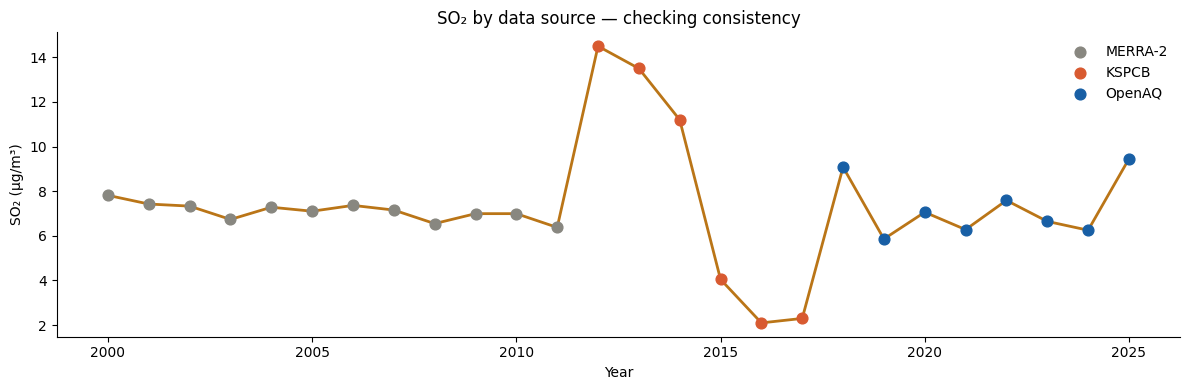

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_combined["year"], df_combined["so2"],
        color="#BA7517", linewidth=2, marker="o", markersize=5)

# Colour-code by source
sources = {
    "MERRA-2":  df_combined[df_combined["year"] <= 2011],
    "KSPCB":    df_combined[(df_combined["year"] >= 2012) &
                             (df_combined["year"] <= 2017)],
    "OpenAQ":   df_combined[df_combined["year"] >= 2018],
}
colors = {"MERRA-2": "#888780", "KSPCB": "#D85A30", "OpenAQ": "#185FA5"}

for source, data in sources.items():
    ax.scatter(data["year"], data["so2"],
               color=colors[source], s=60, zorder=4, label=source)

ax.set_title("SO₂ by data source — checking consistency")
ax.set_ylabel("SO₂ (µg/m³)")
ax.set_xlabel("Year")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Flag SO2 source for transparency
def so2_source(year):
    if year <= 2011:   return "MERRA-2"
    elif year <= 2017: return "KSPCB"
    else:              return "OpenAQ"

df_combined["so2_source"] = df_combined["year"].apply(so2_source)

# Mark SO2 as unreliable for cross-era comparison
df_combined["so2_reliable"] = df_combined["so2_source"] == "OpenAQ"

print("SO2 reliable years (OpenAQ only):")
print(df_combined[df_combined["so2_reliable"]][["year","so2"]].to_string(index=False))

SO2 reliable years (OpenAQ only):
 year   so2
 2018 9.080
 2019 5.860
 2020 7.060
 2021 6.280
 2022 7.590
 2023 6.648
 2024 6.253
 2025 9.450


In [ ]:
!pip install prophet -q

import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

# Reload raw OpenAQ data
df_raw = pd.read_csv(
    "/content/drive/MyDrive/bangalore_air_quality/df_raw_openaq.csv"
)
df_raw["date"] = pd.to_datetime(df_raw["date"])

# Filter PM2.5 only, clean outliers
df_pm25 = df_raw[
    (df_raw["parameter"] == "pm25") &
    (df_raw["value"] >= 0) &
    (df_raw["value"] < 900)
].copy()

# Monthly means across all stations
df_monthly = (
    df_pm25
    .groupby(df_pm25["date"].dt.to_period("M"))["value"]
    .mean()
    .reset_index()
)
df_monthly["date"] = df_monthly["date"].dt.to_timestamp()
df_monthly.columns = ["ds", "y"]
df_monthly["y"] = df_monthly["y"].round(2)

print(f"Monthly PM2.5 series: {len(df_monthly)} months")
print(df_monthly.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Monthly PM2.5 series: 66 months
        ds     y
2018-03-01 88.47
2018-04-01 57.89
2018-05-01 41.02
2018-08-01 18.36
2018-09-01 25.73
2018-10-01 36.11
2018-11-01 43.42
2019-01-01 61.32
2019-02-01 45.92
2019-04-01 51.67
2019-05-01 39.11
2019-06-01 20.19
2019-07-01 18.72
2019-08-01 16.71
2019-09-01 18.26
2019-10-01 23.67
2019-11-01 28.64
2019-12-01 34.98
2020-01-01 37.52
2020-02-01 38.06
2020-03-01 36.31
2020-04-01 28.32
2020-05-01 25.41
2020-06-01 18.62
2020-07-01 15.31
2020-08-01 22.16
2020-09-01 22.60
2020-10-01 35.62
2020-11-01 32.84
2020-12-01 32.60
2021-01-01 35.61
2021-02-01 44.88
2021-03-01 47.26
2021-04-01 38.18
2021-05-01 19.76
2021-06-01 16.39
2021-07-01 14.33
2021-08-01 38.63
2021-09-01 22.70
2021-10-01 36.74
2021-11-01 34.23
2021-12-01 47.89
2022-01-01 35.41
2022-02-01 44.57
2022-03-01 45.42
2022-04-01 41.26
2022-05-01 36.17
2022-06-01 22.87
2022-0

In [ ]:
import os
print("Files in Drive folder:")
for f in os.listdir("/content/drive/MyDrive/bangalore_air_quality"):
    print(" -", f)

Files in Drive folder:
 - df_raw_openaq.csv
 - openaq_bangalore_annual.csv
 - merra2_bias_check.png
 - df_merra2_raw.csv
 - kspcb_manual.csv
 - bangalore_master.csv
 - 01_trend_analysis.png
 - 02_pollution_vs_vehicles.png
 - 03_prophet_forecast.png
 - 03b_prophet_components.png


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

BASE = "/content/drive/MyDrive/bangalore_air_quality/"

df_combined  = pd.read_csv(BASE + "bangalore_master.csv")
df_raw       = pd.read_csv(BASE + "df_raw_openaq.csv")

print("df_combined shape:", df_combined.shape)
print("df_combined columns:", df_combined.columns.tolist())
print("\ndf_raw shape:", df_raw.shape)
print("df_raw columns:", df_raw.columns.tolist())

Mounted at /content/drive
df_combined shape: (26, 8)
df_combined columns: ['year', 'pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'notes']

df_raw shape: (951628, 6)
df_raw columns: ['station_id', 'station_name', 'sensor_id', 'parameter', 'value', 'date']


In [ ]:
# Build monthly PM2.5 series from raw OpenAQ data
df_pm25 = df_raw[df_raw["parameter"] == "pm25"].copy()
df_pm25["date"] = pd.to_datetime(df_pm25["date"])
df_pm25 = df_pm25[(df_pm25["value"] >= 0) & (df_pm25["value"] < 900)]

df_prophet_raw = (
    df_pm25
    .groupby(pd.Grouper(key="date", freq="MS"))["value"]
    .mean()
    .reset_index()
    .rename(columns={"date": "ds", "value": "y"})
    .dropna()
)

df_prophet_raw["ds"] = pd.to_datetime(df_prophet_raw["ds"])
print(f"\nMonthly PM2.5 series: {len(df_prophet_raw)} months")
print(df_prophet_raw.head())


Monthly PM2.5 series: 66 months
          ds          y
0 2018-03-01  88.466292
1 2018-04-01  57.887435
2 2018-05-01  41.019745
5 2018-08-01  18.359047
6 2018-09-01  25.728514


Training months: 63
Validation months: 3


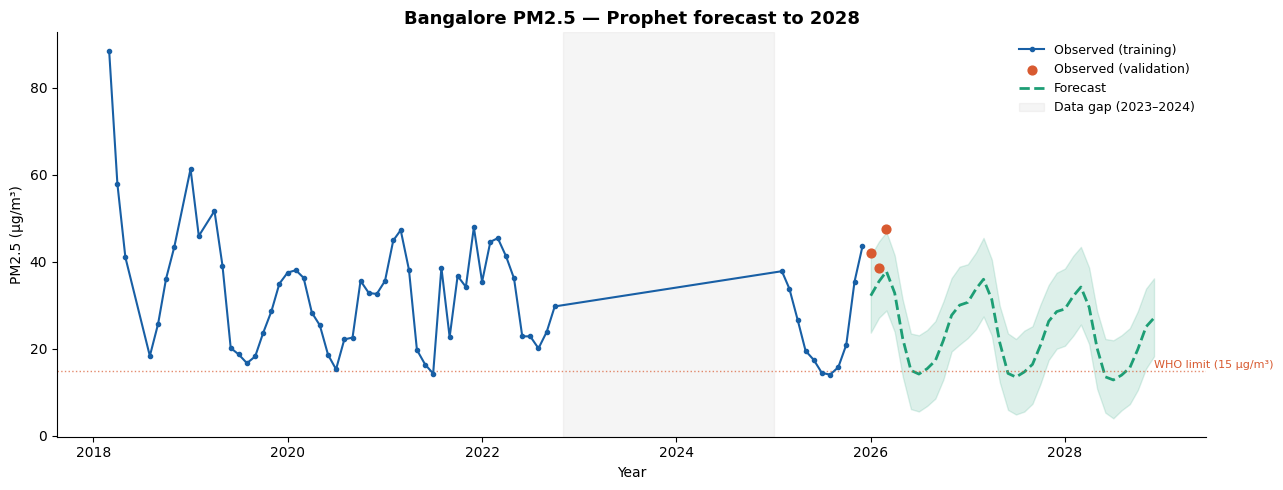

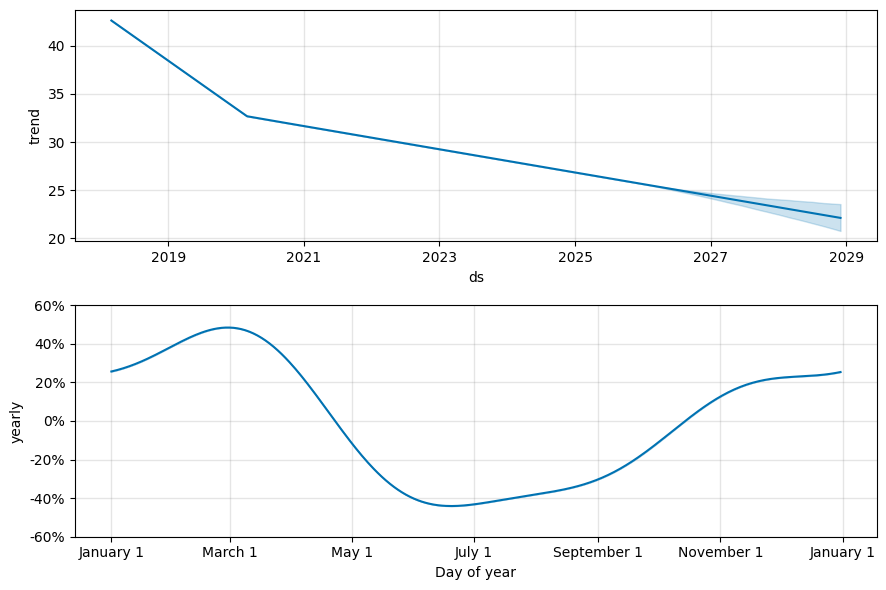

Saved.


In [ ]:
!pip install prophet -q

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Cap training data at end of 2025
df_prophet = df_prophet_raw[df_prophet_raw["ds"] < "2026-01-01"].copy()
df_val     = df_prophet_raw[df_prophet_raw["ds"] >= "2026-01-01"].copy()

print(f"Training months: {len(df_prophet)}")
print(f"Validation months: {len(df_val)}")

# Fit Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",  # better for pollution — monsoon effect is proportional
    changepoint_prior_scale=0.05,       # conservative — avoids overfitting on short series
)

# Add COVID lockdown as a known anomaly
model = Prophet(
    yearly_seasonality=3,      # 3 Fourier terms instead of default 10 — much cleaner
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05,
)
model.fit(df_prophet)

# Forecast through 2028
future = model.make_future_dataframe(periods=36, freq="MS")
forecast = model.predict(future)

# ── Plot 1: Forecast ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Training data
ax.plot(df_prophet["ds"], df_prophet["y"],
        color="#185FA5", linewidth=1.5, marker="o",
        markersize=3, label="Observed (training)", zorder=4)

# Validation data
ax.scatter(df_val["ds"], df_val["y"],
           color="#D85A30", s=40, zorder=5, label="Observed (validation)")

# Forecast line and uncertainty band
forecast_future = forecast[forecast["ds"] > df_prophet["ds"].max()]
ax.plot(forecast_future["ds"], forecast_future["yhat"],
        color="#1D9E75", linewidth=2, linestyle="--", label="Forecast")
ax.fill_between(forecast_future["ds"],
                forecast_future["yhat_lower"],
                forecast_future["yhat_upper"],
                alpha=0.15, color="#1D9E75")

# Gap annotation
ax.axvspan(pd.Timestamp("2022-11-01"), pd.Timestamp("2025-01-01"),
           alpha=0.08, color="#888780", label="Data gap (2023–2024)")

ax.set_title("Bangalore PM2.5 — Prophet forecast to 2028",
             fontsize=13, fontweight="bold")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Year")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.axhline(15, color="#D85A30", linestyle=":", linewidth=1,
           alpha=0.7, label="WHO guideline")
ax.text(forecast["ds"].max(), 15.5, "WHO limit (15 µg/m³)",
        fontsize=8, color="#D85A30")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/bangalore_air_quality/03_prophet_forecast.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Components ────────────────────────────────────────────
fig2 = model.plot_components(forecast)
fig2.savefig("/content/drive/MyDrive/bangalore_air_quality/03b_prophet_components.png",
             dpi=150, bbox_inches="tight")
plt.show()

print("Saved.")

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Data prep ────────────────────────────────────────────────────
# Use annual data from master, PM10 and NO2 only
df_its = df_combined[["year", "pm10", "no2"]].dropna(subset=["pm10", "no2"]).copy()
df_its = df_its[df_its["year"] <= 2022]  # exclude gap years and partial 2025

INTERVENTION = 2017  # BS-VI fuel policy

# ITS variables
df_its["time"]         = df_its["year"] - df_its["year"].min()  # time index 0,1,2...
df_its["post"]         = (df_its["year"] >= INTERVENTION).astype(int)  # 0 before, 1 after
df_its["time_post"]    = df_its["time"] * df_its["post"]  # interaction: slope change after

print("ITS dataset:")
print(df_its.to_string(index=False))

ITS dataset:
 year   pm10   no2  time  post  time_post
 2012 148.00 30.20     0     0          0
 2013 128.00 28.50     1     0          0
 2014 165.00 31.80     2     0          0
 2015 117.65 22.97     3     0          0
 2016 107.00 34.20     4     0          0
 2017  87.10 31.50     5     1          5
 2018  71.88 19.98     6     1          6
 2019  56.66 24.24     7     1          7
 2020  65.37 20.24     8     1          8
 2021  71.42 25.93     9     1          9
 2022  71.46 19.28    10     1         10



── PM10 ITS regression ──
             Coef.  Std.Err.       t  P>|t|   [0.025   0.975]
const      151.600    12.275  12.350  0.000  122.574  180.626
time        -9.235     5.011  -1.843  0.108  -21.085    2.615
post       -65.765    31.619  -2.080  0.076 -140.531    9.001
time_post    7.210     6.282   1.148  0.289   -7.644   22.065

── NO₂ ITS regression ──
            Coef.  Std.Err.      t  P>|t|  [0.025  0.975]
const      29.040     3.589  8.091  0.000  20.553  37.527
time        0.247     1.465  0.169  0.871  -3.218   3.712
post        4.613     9.245  0.499  0.633 -17.247  26.473
time_post  -1.597     1.837 -0.869  0.413  -5.940   2.746


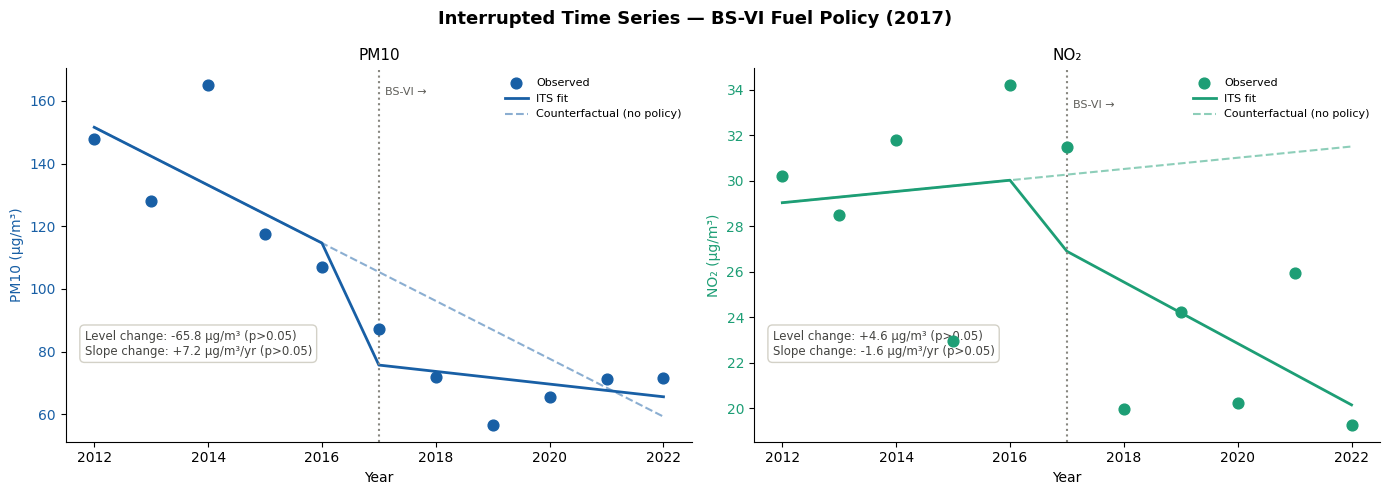

Saved.


In [ ]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Interrupted Time Series — BS-VI Fuel Policy (2017)",
             fontsize=13, fontweight="bold")

results = {}

for ax, col, label, color in [
    (axes[0], "pm10", "PM10", "#185FA5"),
    (axes[1], "no2",  "NO₂",  "#1D9E75"),
]:
    # ── Regression ───────────────────────────────────────────────
    X = sm.add_constant(df_its[["time", "post", "time_post"]])
    y = df_its[col]
    model = sm.OLS(y, X).fit()

    # Counterfactual — what if no intervention (post=0, time_post=0)
    X_counter = df_its[["time", "post", "time_post"]].copy()
    X_counter["post"]      = 0
    X_counter["time_post"] = 0
    X_counter = sm.add_constant(X_counter)
    counterfactual = model.predict(X_counter)

    # Fitted values
    fitted = model.predict(X)

    # ── Plot ─────────────────────────────────────────────────────
    ax.scatter(df_its["year"], df_its[col],
               color=color, s=60, zorder=5, label="Observed")
    ax.plot(df_its["year"], fitted,
            color=color, linewidth=2, label="ITS fit")
    ax.plot(df_its["year"], counterfactual,
            color=color, linewidth=1.5, linestyle="--",
            alpha=0.5, label="Counterfactual (no policy)")
    ax.axvline(INTERVENTION, color="#888780", linestyle=":",
               linewidth=1.5)
    ax.text(INTERVENTION + 0.1, ax.get_ylim()[1] * 0.95,
            "BS-VI →", fontsize=8, color="#5F5E5A")

    # Level change and slope change at intervention
    level_change = model.params["post"]
    slope_change = model.params["time_post"]
    p_level      = model.pvalues["post"]
    p_slope      = model.pvalues["time_post"]

    ax.set_title(f"{label}", fontsize=11, fontweight="500")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"{label} (µg/m³)", color=color)
    ax.tick_params(axis="y", labelcolor=color)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Annotation box
    sig_level = "p<0.05" if p_level < 0.05 else "p>0.05"
    sig_slope = "p<0.05" if p_slope < 0.05 else "p>0.05"
    ax.text(0.03, 0.30,
            f"Level change: {level_change:+.1f} µg/m³ ({sig_level})\n"
            f"Slope change: {slope_change:+.1f} µg/m³/yr ({sig_slope})",
            transform=ax.transAxes, fontsize=8.5,
            verticalalignment="top", color="#444441",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="white", edgecolor="#D3D1C7"))

    results[col] = model
    print(f"\n── {label} ITS regression ──")
    print(model.summary2().tables[1].round(3))

plt.tight_layout()
plt.savefig(BASE + "04_interrupted_time_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

/tmp/ipykernel_6414/1690012307.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


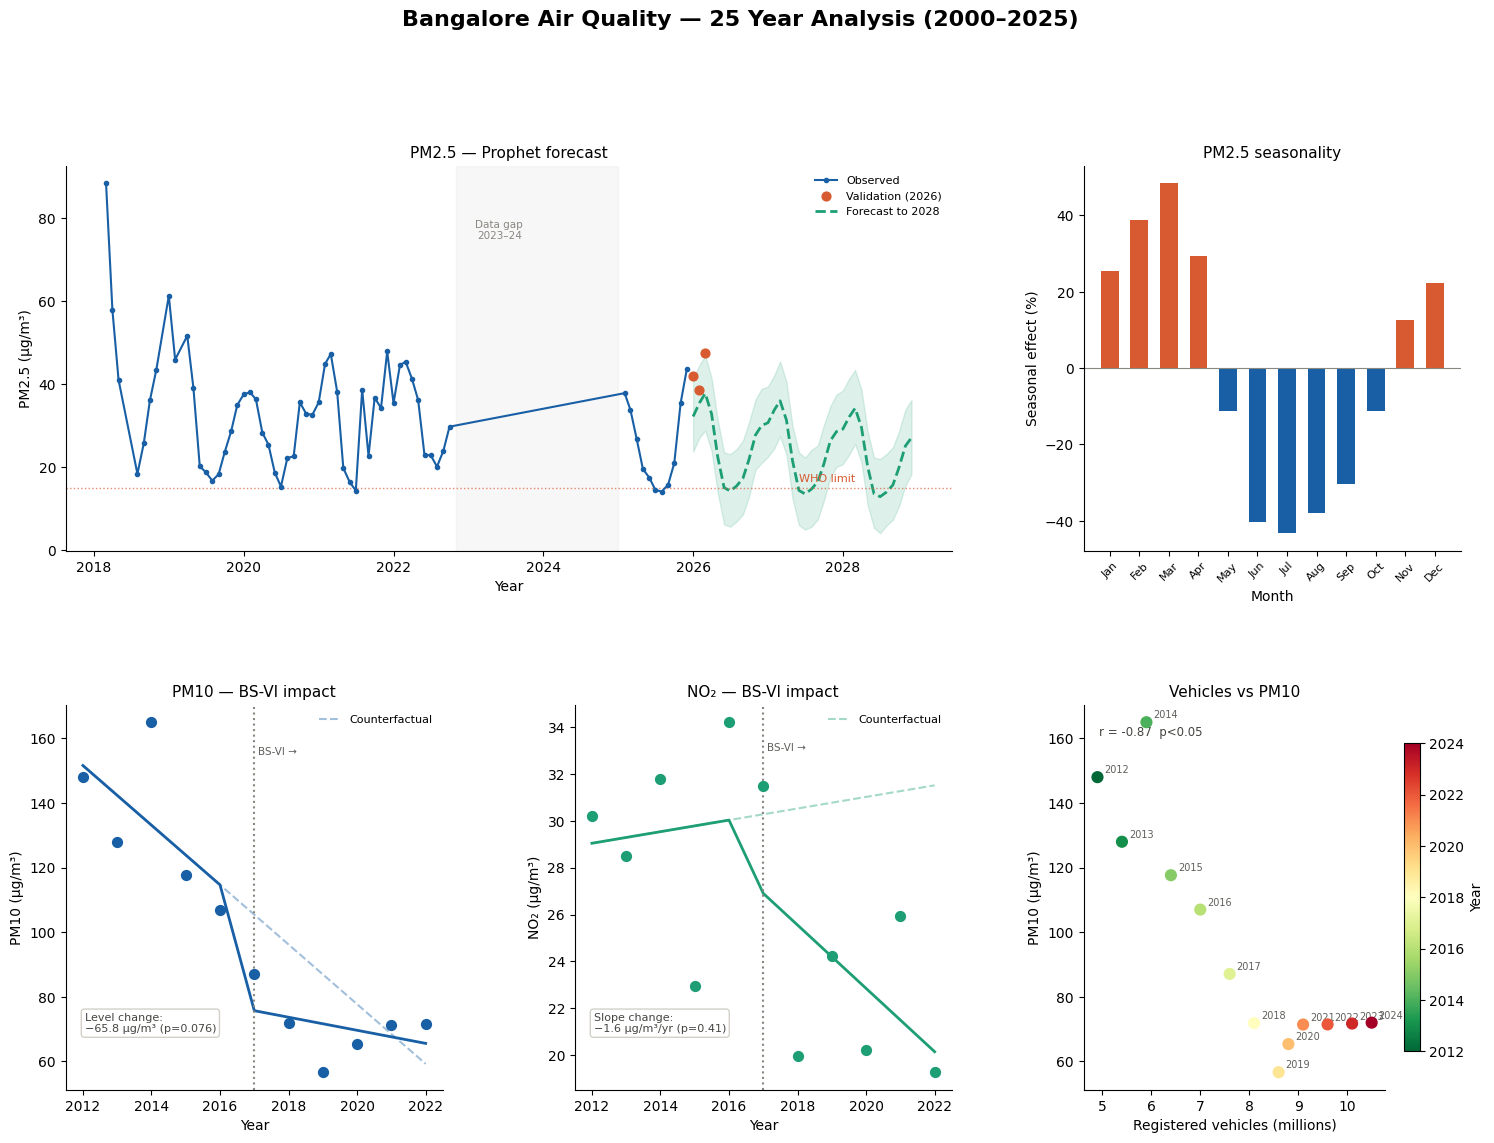

Saved.


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Bangalore Air Quality — 25 Year Analysis (2000–2025)",
             fontsize=16, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])   # PM2.5 forecast — spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # Seasonality
ax3 = fig.add_subplot(gs[1, 0])    # PM10 ITS
ax4 = fig.add_subplot(gs[1, 1])    # NO2 ITS
ax5 = fig.add_subplot(gs[1, 2])    # Vehicles vs PM10 scatter

# ── Panel 1: PM2.5 forecast ───────────────────────────────────────
ax1.plot(df_prophet["ds"], df_prophet["y"],
         color="#185FA5", linewidth=1.5, marker="o",
         markersize=3, label="Observed", zorder=4)
ax1.scatter(df_val["ds"], df_val["y"],
            color="#D85A30", s=40, zorder=5, label="Validation (2026)")
forecast_future = forecast[forecast["ds"] > df_prophet["ds"].max()]
ax1.plot(forecast_future["ds"], forecast_future["yhat"],
         color="#1D9E75", linewidth=2, linestyle="--", label="Forecast to 2028")
ax1.fill_between(forecast_future["ds"],
                 forecast_future["yhat_lower"],
                 forecast_future["yhat_upper"],
                 alpha=0.15, color="#1D9E75")
ax1.axvspan(pd.Timestamp("2022-11-01"), pd.Timestamp("2025-01-01"),
            alpha=0.06, color="#888780")
ax1.text(pd.Timestamp("2023-06-01"), 75,
         "Data gap\n2023–24", fontsize=7.5, color="#888780", ha="center")
ax1.axhline(15, color="#D85A30", linestyle=":", linewidth=1, alpha=0.7)
ax1.text(pd.Timestamp("2027-06-01"), 16.5,
         "WHO limit", fontsize=8, color="#D85A30")
ax1.set_title("PM2.5 — Prophet forecast", fontsize=11, fontweight="500")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.set_xlabel("Year")
ax1.legend(frameon=False, fontsize=8)
ax1.spines[["top","right"]].set_visible(False)

# ── Panel 2: Seasonality ──────────────────────────────────────────
seasonal = forecast[["ds","yearly"]].copy()
seasonal["month"] = pd.to_datetime(seasonal["ds"]).dt.month
monthly_seasonal = seasonal.groupby("month")["yearly"].mean()
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]
colors_bar = ["#D85A30" if v > 0 else "#185FA5"
              for v in monthly_seasonal.values]
ax2.bar(months, monthly_seasonal.values * 100,
        color=colors_bar, edgecolor="none", width=0.6)
ax2.axhline(0, color="#888780", linewidth=0.8)
ax2.set_title("PM2.5 seasonality", fontsize=11, fontweight="500")
ax2.set_ylabel("Seasonal effect (%)")
ax2.set_xlabel("Month")
ax2.tick_params(axis="x", rotation=45, labelsize=8)
ax2.spines[["top","right"]].set_visible(False)

# ── Panel 3: PM10 ITS ─────────────────────────────────────────────
X = sm.add_constant(df_its[["time","post","time_post"]])
pm10_model = results["pm10"]
fitted_pm10 = pm10_model.predict(X)
X_c = df_its[["time","post","time_post"]].copy()
X_c["post"] = 0; X_c["time_post"] = 0
X_c = sm.add_constant(X_c)
counter_pm10 = pm10_model.predict(X_c)

ax3.scatter(df_its["year"], df_its["pm10"],
            color="#185FA5", s=50, zorder=5)
ax3.plot(df_its["year"], fitted_pm10,
         color="#185FA5", linewidth=2)
ax3.plot(df_its["year"], counter_pm10,
         color="#185FA5", linewidth=1.5,
         linestyle="--", alpha=0.4, label="Counterfactual")
ax3.axvline(2017, color="#888780", linestyle=":", linewidth=1.5)
ax3.text(2017.1, 155, "BS-VI →", fontsize=7.5, color="#5F5E5A")
ax3.text(0.05, 0.15,
         "Level change:\n−65.8 µg/m³ (p=0.076)",
         transform=ax3.transAxes, fontsize=8, color="#444441",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", edgecolor="#D3D1C7"))
ax3.set_title("PM10 — BS-VI impact", fontsize=11, fontweight="500")
ax3.set_ylabel("PM10 (µg/m³)")
ax3.set_xlabel("Year")
ax3.legend(frameon=False, fontsize=8)
ax3.spines[["top","right"]].set_visible(False)

# ── Panel 4: NO2 ITS ──────────────────────────────────────────────
no2_model  = results["no2"]
fitted_no2 = no2_model.predict(X)
counter_no2 = no2_model.predict(X_c)

ax4.scatter(df_its["year"], df_its["no2"],
            color="#1D9E75", s=50, zorder=5)
ax4.plot(df_its["year"], fitted_no2,
         color="#1D9E75", linewidth=2)
ax4.plot(df_its["year"], counter_no2,
         color="#1D9E75", linewidth=1.5,
         linestyle="--", alpha=0.4, label="Counterfactual")
ax4.axvline(2017, color="#888780", linestyle=":", linewidth=1.5)
ax4.text(2017.1, 33, "BS-VI →", fontsize=7.5, color="#5F5E5A")
ax4.text(0.05, 0.15,
         "Slope change:\n−1.6 µg/m³/yr (p=0.41)",
         transform=ax4.transAxes, fontsize=8, color="#444441",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", edgecolor="#D3D1C7"))
ax4.set_title("NO₂ — BS-VI impact", fontsize=11, fontweight="500")
ax4.set_ylabel("NO₂ (µg/m³)")
ax4.set_xlabel("Year")
ax4.legend(frameon=False, fontsize=8)
ax4.spines[["top","right"]].set_visible(False)

# ── Panel 5: Vehicles vs PM10 scatter ────────────────────────────
data_scatter = df_combined[
    df_combined["pm10"].notna() &
    df_combined["vehicles_millions"].notna()
].copy()
sc = ax5.scatter(data_scatter["vehicles_millions"],
                 data_scatter["pm10"],
                 c=data_scatter["year"],
                 cmap="RdYlGn_r", s=60, zorder=4)
for _, row in data_scatter.iterrows():
    ax5.annotate(str(int(row["year"])),
                 (row["vehicles_millions"], row["pm10"]),
                 textcoords="offset points",
                 xytext=(5, 3), fontsize=7, color="#5F5E5A")
r, p = stats.pearsonr(data_scatter["vehicles_millions"],
                      data_scatter["pm10"])
ax5.set_title("Vehicles vs PM10", fontsize=11, fontweight="500")
ax5.set_xlabel("Registered vehicles (millions)")
ax5.set_ylabel("PM10 (µg/m³)")
ax5.text(0.05, 0.92, f"r = {r:.2f}  p<0.05",
         transform=ax5.transAxes, fontsize=8.5, color="#444441")
plt.colorbar(sc, ax=ax5, label="Year", shrink=0.8)
ax5.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(BASE + "05_summary_figure.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")